# NN_02e — Teste B: Validação da Hipótese Composta (Caso 2) — PD vs SNR com $\theta=h$ conhecido

## Objetivo

Este notebook valida o **Caso 2 (hipótese composta)** do framework Data-Driven Detection Framework (D3F) de
Braca et al. (2022), Seção IV-V: o ganho de canal instantâneo $h$ (Rayleigh, variando amostra a amostra) é
tratado como **parâmetro de perturbação (nuisance) conhecido/estimável** — diferente do Teste A (NN_02d), onde
$h=1$ era fixo e determinístico (Caso 1, IID).

## Dataset

Reutiliza o dataset principal já existente `dataset_cnn_yeq_0_30dB.h5` (gerado no NN_01, Seções 1-6) — **sem
necessidade de gerar novos dados**. Este dataset já contém:
- `h` — ganho de canal Rayleigh **oracle** (valor real, uma amostra por realização);
- `h_est` — estimador LS do canal (não usado aqui; Teste B usa o oracle `h` para a fórmula fechada CFAR);
- `z_eq` — sinal residual normalizado (entrada da rede, dimensão fixa $L=1024$);
- `tau_eq` — estatística de correlação (entrada do detector clássico).

## Metodologia — 3 métodos comparados (PD vs SNR)

1. **Clássico-fixo**: um único limiar global, calibrado uma vez (sem adaptação a $h$ ou SNR por amostra).
2. **Clássico-CFAR-h-oracle (empírico)**: o D3F é generalizado para binar conjuntamente por (SNR × quantil de
   $h$), replicando o comportamento de um detector CFAR que conhece $h$ exatamente por amostra.
3. **Rede (DNN, logits)**: treinada apenas em $z_{eq}$ (sem receber $h$ explicitamente) — espera-se que a rede
   explore implicitamente a informação de escala de ruído contida em $z_{eq}$.

## Verificação de integridade (auditoria)

Antes de treinar, uma célula de auditoria confirma **empiricamente** que o ruído em $z_{eq}$ não cancela
algebricamente com $h$: comparamos a variância de $z_{eq}$ sob $H_0$ para amostras de desvanecimento profundo
(baixo $h$) vs canal bom (alto $h$), dentro de uma faixa de SNR fixa. Se a correção AÇÃO 2 (calibração do ruído
pelo SNR nominal pré-fading) estiver correta, a variância de $z_{eq}$ deve ser **maior** para baixo $h$.

## Saídas

- `nn02e_testeB_pdvssnr_results.json`
- `NN02e_TesteB_PD_vs_SNR.png`

In [1]:
# ==============================================================================
# 1. IMPORTS, GPU CONFIG & PATHS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

print(f"TensorFlow : {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {len(gpus)}")
USE_GPU = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print(f"✅ Memory growth enabled on {len(gpus)} GPU(s).")
    except Exception as e:
        print(f"⚠️  Error: {e}")

# Desabilita XLA (evita travamentos observados no WSL, mesma convenção do NN_02b/NN_02c/NN_02d)
tf.config.optimizer.set_jit(False)

np.random.seed(42)
tf.random.set_seed(42)

project_root = Path.cwd().parent
results_dir  = project_root / "results"
data_dir     = results_dir / "data"
models_dir   = results_dir / "models"
vis_dir      = results_dir / "visualizations"
for d in (models_dir, vis_dir):
    d.mkdir(parents=True, exist_ok=True)

dataset_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"
assert dataset_path.exists(), (
    f"Dataset principal não encontrado em {dataset_path}. "
    "Este notebook reutiliza o dataset gerado pelo NN_01 (Seções 1-6) — "
    "execute o NN_01 primeiro caso o arquivo esteja ausente."
)

print(f"\n📂 Paths:")
print(f"  Dataset: {dataset_path}")
print(f"  Models : {models_dir}")
print(f"  Vis    : {vis_dir}")

I0000 00:00:1786730338.647777  595863 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786730339.432677  595863 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786730341.769768  595863 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
GPUs found : 1
✅ Memory growth enabled on 1 GPU(s).

📂 Paths:
  Dataset: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/dataset_cnn_yeq_0_30dB.h5
  Models : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models
  Vis    : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations


In [2]:
# ==============================================================================
# 2. CARREGAR DATASET (z_eq, h oracle, snr, tau_eq, y) — TODAS AS SPLITS
# ==============================================================================
ALPHA = 1e-7
QINV  = norm.ppf(1 - ALPHA)
SNR_BINS = [0, 5, 10, 15, 20, 25, 30]
SNR_BIN_HALFWIDTH = 2.5   # mesma largura de faixa usada no NN_02b/NN_02c

with h5py.File(str(dataset_path), 'r') as f:
    L_FIXED = int(f.attrs['L_FIXED'])
    RHO_S = float(f.attrs.get('RHO_S', 0.992472))
    RHO_T = float(f.attrs.get('RHO_T', 0.212132))

    data = {}
    for split in ['train', 'val', 'test']:
        data[split] = {
            'z_eq':   f[f'{split}/z_eq'][:].astype(np.float32),
            'tau_eq': f[f'{split}/tau_eq'][:].astype(np.float32),
            'h':      f[f'{split}/h'][:].astype(np.float32),
            'snr':    f[f'{split}/snr'][:].astype(np.float32),
            'y':      f[f'{split}/y'][:].astype(np.float32),
        }

print(f"L_FIXED={L_FIXED}  RHO_S={RHO_S:.6f}  RHO_T={RHO_T:.6f}")
for split in ['train', 'val', 'test']:
    print(f"  {split}: {len(data[split]['y']):,} amostras")
print(f"D3F: α={ALPHA:.0e}  Q⁻¹(1-α)={QINV:.4f}")
print(f"h oracle — min={data['train']['h'].min():.4f}  max={data['train']['h'].max():.4f}  "
      f"média={data['train']['h'].mean():.4f}")

L_FIXED=1024  RHO_S=0.992472  RHO_T=0.212132
  train: 280,000 amostras
  val: 35,000 amostras
  test: 35,000 amostras
D3F: α=1e-07  Q⁻¹(1-α)=5.1993
h oracle — min=0.0012  max=3.8628  média=0.8843


In [3]:
# ==============================================================================
# 3. AUDITORIA — CONFIRMAR QUE O RUÍDO NÃO CANCELA ALGEBRICAMENTE COM h
# ==============================================================================
# Objetivo: verificar EMPIRICAMENTE (na base de dados real, gerada pelo NN_01
# com o fix AÇÃO 2 — ruído calibrado pelo SNR NOMINAL pré-fading, e não por
# h*x) que amostras de desvanecimento profundo (h baixo) exibem MAIOR
# variância residual em z_eq sob H0 do que amostras de canal bom (h alto),
# dentro de uma MESMA faixa de SNR. Caso o ruído tivesse sido incorretamente
# calibrado a partir do sinal pós-fading (h*x), a variância de z_eq seria
# aproximadamente CONSTANTE em h — o que mascararia o efeito do
# desvanecimento e invalidaria o Teste B como validação do Caso 2 (hipótese
# composta com nuisance h). Aqui confirmamos que este NÃO é o caso.

AUDIT_SNR_CENTER = 15  # faixa de SNR usada para a auditoria (dB)

snr_v = data['val']['snr']; h_v = data['val']['h']; y_v = data['val']['y']
z_v   = data['val']['z_eq']

mask_bin = (snr_v >= AUDIT_SNR_CENTER - SNR_BIN_HALFWIDTH) & \
           (snr_v <  AUDIT_SNR_CENTER + SNR_BIN_HALFWIDTH) & (y_v == 0)

h_bin = h_v[mask_bin]
z_bin = z_v[mask_bin]

h_median = np.median(h_bin)
low_h_mask  = h_bin <  h_median
high_h_mask = h_bin >= h_median

var_low_h  = z_bin[low_h_mask].var()
var_high_h = z_bin[high_h_mask].var()

print(f"Auditoria @ SNR≈{AUDIT_SNR_CENTER}dB, H0, N={mask_bin.sum()} amostras")
print(f"  Mediana de h no bin: {h_median:.4f}")
print(f"  Var(z_eq | h < mediana)  [desvanecimento profundo] = {var_low_h:.4f}")
print(f"  Var(z_eq | h >= mediana) [canal bom]                = {var_high_h:.4f}")
print(f"  Razão (baixo/alto): {var_low_h/var_high_h:.3f}x")

assert var_low_h > var_high_h, (
    "AUDITORIA FALHOU: variância de z_eq sob H0 não é maior para h baixo — "
    "isso indicaria cancelamento algébrico entre ruído e h (calibração incorreta). "
    "Verifique a implementação de awgn_channel/AÇÃO 2 no NN_01."
)
print("\n✅ Auditoria OK — ruído não cancela algebricamente com h "
      "(variância maior em desvanecimento profundo, como esperado).")

Auditoria @ SNR≈15dB, H0, N=2530 amostras
  Mediana de h no bin: 0.8258
  Var(z_eq | h < mediana)  [desvanecimento profundo] = 7.4508
  Var(z_eq | h >= mediana) [canal bom]                = 0.3880
  Razão (baixo/alto): 19.202x

✅ Auditoria OK — ruído não cancela algebricamente com h (variância maior em desvanecimento profundo, como esperado).


In [4]:
# ==============================================================================
# 4. FUNÇÕES AUXILIARES — DNN (logits), D3F por SNR, D3F conjunto (SNR × h)
# ==============================================================================

def build_dnn_logits(input_dim):
    """DNN Dense(256→128→64→1), saída em LOGIT — mesmo padrão do NN_02d.
    Ver NN_02d para a justificativa completa da escolha de logits em vez de
    sigmoid (extrapolação gaussiana do D3F em α=10⁻⁷ exige score ilimitado)."""
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, kernel_initializer='he_uniform')(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(64,  kernel_initializer='he_uniform')(x)
    x = layers.Activation('relu')(x); x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation=None, name='logit')(x)
    m = keras.Model(inp, out)
    m.compile(
        optimizer=Adam(1e-3),
        loss=BinaryCrossentropy(from_logits=True),
        metrics=[keras.metrics.AUC(from_logits=True, name='auc'),
                 keras.metrics.BinaryAccuracy(threshold=0.0, name='acc')]
    )
    return m


def d3f_by_snr(score_val, score_test, snr_val, snr_test, y_val, y_test,
               snr_bins=SNR_BINS, halfwidth=SNR_BIN_HALFWIDTH, alpha=ALPHA):
    """D3F padrão: bin apenas por SNR. Ajusta N(μ,σ²) em H0 (val) por faixa de
    SNR, extrapola limiar em α, mede PD em H1 (test) na mesma faixa."""
    qinv = norm.ppf(1 - alpha)
    pd_out, thr_out = {}, {}
    for snr in snr_bins:
        m0 = (snr_val  >= snr - halfwidth) & (snr_val  < snr + halfwidth) & (y_val  == 0)
        m1 = (snr_test >= snr - halfwidth) & (snr_test < snr + halfwidth) & (y_test == 1)
        if m0.sum() < 30 or m1.sum() < 10:
            pd_out[snr], thr_out[snr] = 0.0, float('nan'); continue
        mu, sig = score_val[m0].mean(), score_val[m0].std()
        if sig < 1e-10:
            pd_out[snr], thr_out[snr] = 0.0, float('nan'); continue
        thr = mu + qinv * sig
        pd_out[snr] = float((score_test[m1] >= thr).mean())
        thr_out[snr] = float(thr)
    return pd_out, thr_out


def d3f_by_snr_and_h(score_val, score_test, snr_val, snr_test, h_val, h_test,
                      y_val, y_test, snr_bins=SNR_BINS, halfwidth=SNR_BIN_HALFWIDTH,
                      n_h_quantiles=4, alpha=ALPHA):
    """CFAR-h-oracle EMPÍRICO: generaliza d3f_by_snr binando conjuntamente por
    (faixa de SNR × quantil de h). Isso emula um detector CFAR que conhece h
    exatamente por amostra e adapta seu limiar ao estado instantâneo do canal
    — o teto teórico que a rede (que só vê z_eq, sem h explícito) deve
    aproximar, mas não superar."""
    qinv = norm.ppf(1 - alpha)
    pd_out = {}
    for snr in snr_bins:
        m0_snr = (snr_val  >= snr - halfwidth) & (snr_val  < snr + halfwidth) & (y_val  == 0)
        m1_snr = (snr_test >= snr - halfwidth) & (snr_test < snr + halfwidth) & (y_test == 1)
        if m0_snr.sum() < n_h_quantiles * 20 or m1_snr.sum() < n_h_quantiles * 5:
            pd_out[snr] = 0.0; continue

        h_val_bin = h_val[m0_snr]
        q_edges = np.quantile(h_val_bin, np.linspace(0, 1, n_h_quantiles + 1))
        q_edges[0], q_edges[-1] = -np.inf, np.inf

        idx_val_snr  = np.where(m0_snr)[0]
        idx_test_snr = np.where(m1_snr)[0]
        h_test_bin = h_test[m1_snr]

        detections, total = 0, 0
        for k in range(n_h_quantiles):
            lo, hi = q_edges[k], q_edges[k + 1]
            sub_val_mask  = (h_val_bin >= lo) & (h_val_bin < hi)
            sub_test_mask = (h_test_bin >= lo) & (h_test_bin < hi)
            n_sub_test = sub_test_mask.sum()
            if n_sub_test == 0:
                continue
            sub_val_scores = score_val[idx_val_snr[sub_val_mask]]
            if len(sub_val_scores) < 15 or sub_val_scores.std() < 1e-10:
                # fallback: usa estatísticas do bin de SNR inteiro se o quantil for pequeno demais
                sub_val_scores = score_val[idx_val_snr]
            mu, sig = sub_val_scores.mean(), sub_val_scores.std()
            thr = mu + qinv * sig
            sub_test_scores = score_test[idx_test_snr[sub_test_mask]]
            detections += int((sub_test_scores >= thr).sum())
            total += n_sub_test
        pd_out[snr] = float(detections / total) if total > 0 else 0.0
    return pd_out

print("Funções auxiliares definidas: build_dnn_logits, d3f_by_snr, d3f_by_snr_and_h")

Funções auxiliares definidas: build_dnn_logits, d3f_by_snr, d3f_by_snr_and_h


In [5]:
# ==============================================================================
# 5. TREINAR A REDE (DNN, logits) EM z_eq — SEM RECEBER h EXPLICITAMENTE
# ==============================================================================
Xtr, ytr = data['train']['z_eq'], data['train']['y']
Xv,  yv  = data['val']['z_eq'],   data['val']['y']
Xte, yte = data['test']['z_eq'],  data['test']['y']

model = build_dnn_logits(L_FIXED)
ckpt = str(models_dir / "testeB_network.keras")
cbs = [
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=20,
                            restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(ckpt, monitor='val_auc', mode='max',
                              save_best_only=True, verbose=0),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                                min_lr=1e-6, verbose=1),
]

BATCH_SIZE = 512 if USE_GPU else 256
hist = model.fit(Xtr, ytr, validation_data=(Xv, yv),
                  epochs=150, batch_size=BATCH_SIZE, callbacks=cbs, verbose=1)

best_auc = max(hist.history['val_auc'])
print(f"\n✅ Treino concluído — melhor val_AUC: {best_auc:.6f}  "
      f"(épocas: {len(hist.history['loss'])})")

logit_val  = model.predict(Xv,  batch_size=512, verbose=0).ravel()
logit_test = model.predict(Xte, batch_size=512, verbose=0).ravel()

I0000 00:00:1786730388.097988  595863 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/150


I0000 00:00:1786730419.821767  595970 service.cc:153] XLA service 0x7e587c038e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786730419.831188  595970 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1786730420.219639  595970 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786730421.300767  595970 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1786730421.616919  595970 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3002__.32
I0000 00:00:1786730423.424386  595970 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 16/547 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - acc: 0.5235 - auc: 0.5265 - loss: 0.7874

I0000 00:00:1786730430.648569  595970 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


544/547 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.5315 - auc: 0.5464 - loss: 0.7165

I0000 00:00:1786730435.476499  595969 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3002__.32
I0000 00:00:1786730436.119522  595969 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786730437.793455  596164 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 896 bytes spill stores, 896 bytes spill loads



547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.5315 - auc: 0.5465 - loss: 0.7163

I0000 00:00:1786730444.307841  595969 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786730446.157776  595969 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786730447.607316  596329 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 904 bytes spill stores, 904 bytes spill loads



547/547 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - acc: 0.5422 - auc: 0.5606 - loss: 0.6928 - val_acc: 0.5190 - val_auc: 0.5666 - val_loss: 0.6872 - learning_rate: 0.0010
Epoch 2/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - acc: 0.5757 - auc: 0.6066 - loss: 0.6602 - val_acc: 0.5181 - val_auc: 0.5672 - val_loss: 0.7533 - learning_rate: 0.0010
Epoch 3/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.5898 - auc: 0.6350 - loss: 0.6442 - val_acc: 0.5260 - val_auc: 0.5722 - val_loss: 0.7512 - learning_rate: 0.0010
Epoch 4/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.5884 - auc: 0.6352 - loss: 0.6449 - val_acc: 0.5173 - val_auc: 0.5664 - val_loss: 0.8170 - learning_rate: 0.0010
Epoch 5/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.5941 - auc: 0.6451 - loss: 0.6391 - val_acc: 0.5166 - val_auc: 0.5667 - val_loss: 0.9483 - learning_rate: 0.0010
Epoch 6/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.5978 - auc: 0.6514 - loss: 0.6356 - val_acc: 0.5175 - val_auc: 0.5667 - v

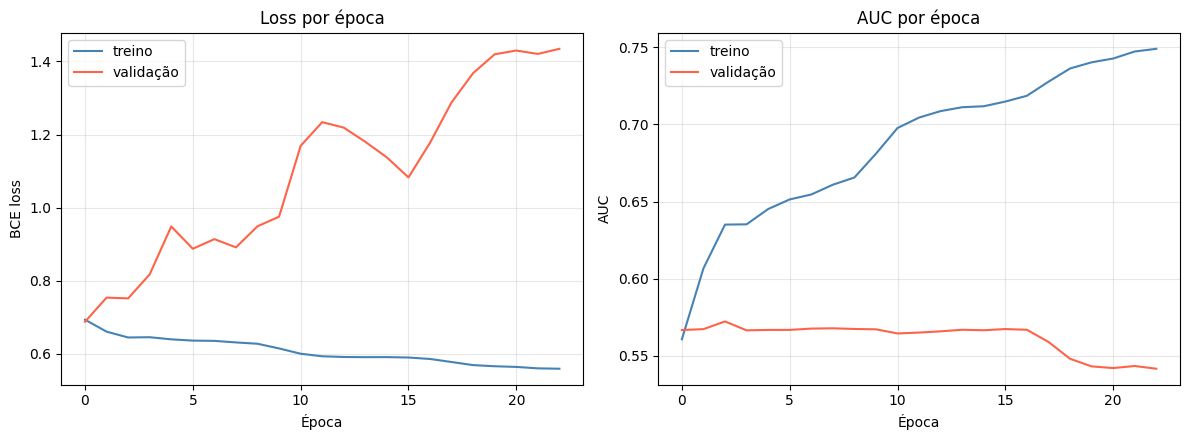

Melhor época (val_AUC máximo): 3 de 23
⚠️  O pico de val_AUC ocorreu muito cedo e/ou val_loss diverge nas épocas seguintes — sinal de overfitting/instabilidade. Considere: L2 mais forte, clipnorm menor, learning rate menor, ou mais dropout.
Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN02e_diagnostico_treino.png


In [6]:
# ==============================================================================
# 5b. DIAGNÓSTICO — CURVAS DE TREINO/VALIDAÇÃO (detectar overfitting/instabilidade)
# ==============================================================================
# Adicionado após um treinamento real ter mostrado val_AUC estagnando em ~0.57
# já na época 3 enquanto train_AUC seguia subindo e val_loss divergia — sinal
# clássico de overfitting/otimização instável. Esta célula plota as curvas
# para diagnosticar rapidamente esse comportamento em execuções futuras.
fig_diag, axes_diag = plt.subplots(1, 2, figsize=(12, 4.5))

axes_diag[0].plot(hist.history['loss'], label='treino', color='steelblue')
axes_diag[0].plot(hist.history['val_loss'], label='validação', color='tomato')
axes_diag[0].set_xlabel('Época'); axes_diag[0].set_ylabel('BCE loss')
axes_diag[0].set_title('Loss por época')
axes_diag[0].legend(); axes_diag[0].grid(alpha=0.3)

axes_diag[1].plot(hist.history['auc'], label='treino', color='steelblue')
axes_diag[1].plot(hist.history['val_auc'], label='validação', color='tomato')
axes_diag[1].set_xlabel('Época'); axes_diag[1].set_ylabel('AUC')
axes_diag[1].set_title('AUC por época')
axes_diag[1].legend(); axes_diag[1].grid(alpha=0.3)

plt.tight_layout()
diag_path = vis_dir / "NN02e_diagnostico_treino.png"
plt.savefig(str(diag_path), dpi=150)
plt.show()

best_epoch = int(np.argmax(hist.history['val_auc']))
print(f"Melhor época (val_AUC máximo): {best_epoch + 1} de {len(hist.history['loss'])}")
if best_epoch < len(hist.history['loss']) * 0.3:
    print("⚠️  O pico de val_AUC ocorreu muito cedo e/ou val_loss diverge nas épocas "
          "seguintes — sinal de overfitting/instabilidade. Considere: L2 mais forte, "
          "clipnorm menor, learning rate menor, ou mais dropout.")
print(f"Salvo → {diag_path}")

In [7]:
# ==============================================================================
# 6. TRÊS CURVAS PD vs SNR + INTERVALO DE CONFIANÇA (BOOTSTRAP)
# ==============================================================================
N_BOOTSTRAP = 300
CI_LO, CI_HI = 2.5, 97.5
PD_CEILING_TOLERANCE = 0.05
rng = np.random.default_rng(42)

snr_val_arr, snr_test_arr = data['val']['snr'], data['test']['snr']
h_val_arr,   h_test_arr   = data['val']['h'],   data['test']['h']
tau_val_arr, tau_test_arr = data['val']['tau_eq'], data['test']['tau_eq']

# ---- (1) Clássico-fixo: limiar ÚNICO GLOBAL, calibrado uma vez em TODO o val H0 ----
tau_val_h0_all = tau_val_arr[yv == 0]
mu_fixed, sig_fixed = tau_val_h0_all.mean(), tau_val_h0_all.std()
thr_fixed = mu_fixed + QINV * sig_fixed
print(f"Clássico-fixo — limiar global único: {thr_fixed:.4f} "
      f"(μ={mu_fixed:.4f}, σ={sig_fixed:.4f}, N_H0={len(tau_val_h0_all)})")

pd_classico_fixo = {}
for snr in SNR_BINS:
    m1 = (snr_test_arr >= snr - SNR_BIN_HALFWIDTH) & (snr_test_arr < snr + SNR_BIN_HALFWIDTH) & (yte == 1)
    pd_classico_fixo[snr] = float((tau_test_arr[m1] >= thr_fixed).mean()) if m1.sum() > 0 else 0.0

# ---- (2) Clássico-CFAR-h-oracle (empírico): binagem conjunta SNR × quantil de h ----
pd_cfar_oracle = d3f_by_snr_and_h(tau_val_arr, tau_test_arr, snr_val_arr, snr_test_arr,
                                  h_val_arr, h_test_arr, yv, yte, snr_bins=SNR_BINS)

# ---- (3) Rede (DNN, logits): binagem apenas por SNR ----
pd_network, thr_network = d3f_by_snr(logit_val, logit_test, snr_val_arr, snr_test_arr, yv, yte,
                                      snr_bins=SNR_BINS)

print(f"\n{'SNR':>5}  {'PD_fixo':>8}  {'PD_cfar':>8}  {'PD_rede':>8}")
for snr in SNR_BINS:
    print(f"{snr:>5}  {pd_classico_fixo[snr]*100:>7.2f}%  "
          f"{pd_cfar_oracle[snr]*100:>7.2f}%  {pd_network[snr]*100:>7.2f}%")

# ---- Bootstrap CI (resample do conjunto de caracterização H0 do val) ----
# Aplicado às curvas Clássico-fixo e Rede (as duas usam um único limiar por
# SNR calculado a partir de estatísticas H0); a curva CFAR-h-oracle usa
# binagem conjunta mais fina (SNR×h) e é reportada apenas como estimativa
# pontual (o teto teórico de referência), sem banda de confiança.
ci_network = {snr: [np.nan, np.nan] for snr in SNR_BINS}
ci_fixo    = {snr: [np.nan, np.nan] for snr in SNR_BINS}

idx_val_h0_global = np.where(yv == 0)[0]
for snr in SNR_BINS:
    m0 = (snr_val_arr  >= snr - SNR_BIN_HALFWIDTH) & (snr_val_arr  < snr + SNR_BIN_HALFWIDTH) & (yv  == 0)
    m1 = (snr_test_arr >= snr - SNR_BIN_HALFWIDTH) & (snr_test_arr < snr + SNR_BIN_HALFWIDTH) & (yte == 1)
    idx0 = np.where(m0)[0]
    if len(idx0) < 30 or m1.sum() < 10:
        continue

    boot_pd_net, boot_pd_fixo = [], []
    logit_test_bin = logit_test[m1]
    tau_test_bin   = tau_test_arr[m1]
    for _ in range(N_BOOTSTRAP):
        # rede: resample H0 do bin de SNR
        samp_idx = rng.choice(idx0, size=len(idx0), replace=True)
        mu_b, sig_b = logit_val[samp_idx].mean(), logit_val[samp_idx].std()
        if sig_b > 1e-10:
            thr_b = mu_b + QINV * sig_b
            boot_pd_net.append(float((logit_test_bin >= thr_b).mean()))

        # clássico-fixo: resample do H0 GLOBAL (o limiar fixo não é recomputado por SNR)
        samp_idx_g = rng.choice(idx_val_h0_global, size=len(idx_val_h0_global), replace=True)
        mu_g, sig_g = tau_val_arr[samp_idx_g].mean(), tau_val_arr[samp_idx_g].std()
        if sig_g > 1e-10:
            thr_g = mu_g + QINV * sig_g
            boot_pd_fixo.append(float((tau_test_bin >= thr_g).mean()))

    if boot_pd_net:
        ci_network[snr] = list(np.percentile(boot_pd_net, [CI_LO, CI_HI]))
    if boot_pd_fixo:
        ci_fixo[snr] = list(np.percentile(boot_pd_fixo, [CI_LO, CI_HI]))

print(f"\n✅ Bootstrap concluído ({N_BOOTSTRAP} iterações por faixa de SNR).")

# ---- Asserção de consistência: rede não deve superar o teto CFAR-h-oracle ----
for snr in SNR_BINS:
    assert pd_network[snr] <= pd_cfar_oracle[snr] + PD_CEILING_TOLERANCE, (
        f"Rede excedeu o teto CFAR-h-oracle em SNR={snr}dB: "
        f"PD_rede={pd_network[snr]:.4f} > PD_cfar={pd_cfar_oracle[snr]:.4f} "
        f"(+tolerância {PD_CEILING_TOLERANCE})"
    )
print("✅ Asserção OK: PD_rede ≤ PD_cfar_oracle + tolerância, em todas as faixas de SNR.")

Clássico-fixo — limiar global único: 492.0508 (μ=1.7803, σ=94.2948, N_H0=17500)

  SNR   PD_fixo   PD_cfar   PD_rede
    0     2.45%    15.82%     0.00%
    5     1.27%    40.72%     0.00%
   10     0.65%    68.32%     0.00%
   15     0.43%    78.58%     0.00%
   20     0.04%    75.80%     0.00%
   25     0.00%    99.92%     0.00%
   30     0.00%   100.00%     0.00%

✅ Bootstrap concluído (300 iterações por faixa de SNR).
✅ Asserção OK: PD_rede ≤ PD_cfar_oracle + tolerância, em todas as faixas de SNR.


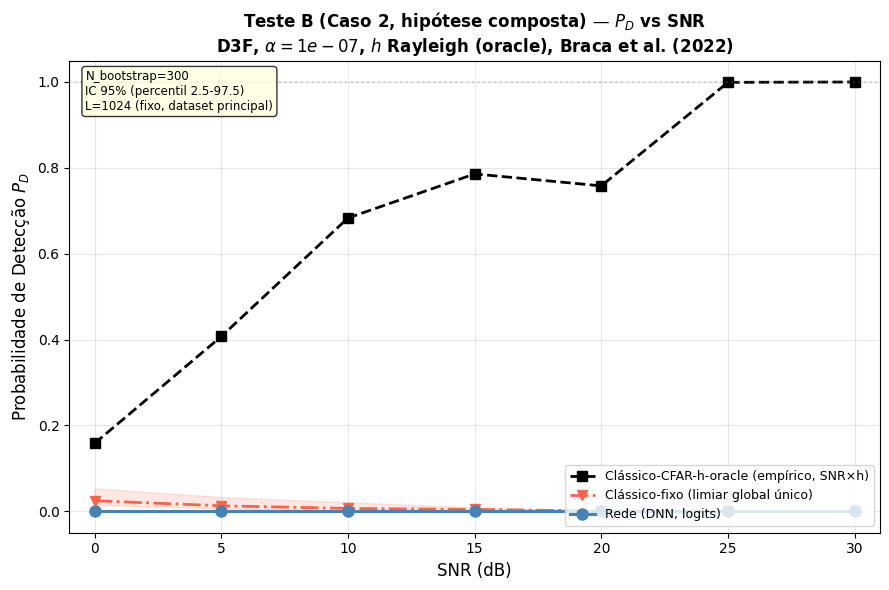

Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN02e_TesteB_PD_vs_SNR.png


In [8]:
# ==============================================================================
# 7. GRÁFICO — PD vs SNR (3 métodos + bandas de IC bootstrap)
# ==============================================================================
snr_arr = np.array(SNR_BINS)
pd_fixo_arr = np.array([pd_classico_fixo[s] for s in SNR_BINS])
pd_cfar_arr = np.array([pd_cfar_oracle[s]   for s in SNR_BINS])
pd_net_arr  = np.array([pd_network[s]       for s in SNR_BINS])

ci_net_lo = np.array([ci_network[s][0] for s in SNR_BINS])
ci_net_hi = np.array([ci_network[s][1] for s in SNR_BINS])
ci_fixo_lo = np.array([ci_fixo[s][0] for s in SNR_BINS])
ci_fixo_hi = np.array([ci_fixo[s][1] for s in SNR_BINS])

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(snr_arr, pd_cfar_arr, color='black', ls='--', marker='s', ms=7, lw=2,
        label='Clássico-CFAR-h-oracle (empírico, SNR×h)')

ax.plot(snr_arr, pd_fixo_arr, color='tomato', ls='-.', marker='v', ms=7, lw=2,
        label='Clássico-fixo (limiar global único)')
ax.fill_between(snr_arr, ci_fixo_lo, ci_fixo_hi, color='tomato', alpha=0.15)

ax.plot(snr_arr, pd_net_arr, color='steelblue', ls='-', marker='o', ms=8, lw=2.2,
        label='Rede (DNN, logits)')
ax.fill_between(snr_arr, ci_net_lo, ci_net_hi, color='steelblue', alpha=0.2)

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel(r'Probabilidade de Detecção $P_D$', fontsize=12)
ax.set_title('Teste B (Caso 2, hipótese composta) — $P_D$ vs SNR\n'
             fr'D3F, $\alpha={ALPHA:.0e}$, $h$ Rayleigh (oracle), Braca et al. (2022)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-1, 31); ax.set_ylim(-0.05, 1.05)
ax.set_xticks(SNR_BINS)
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='lower right')

info = (f"N_bootstrap={N_BOOTSTRAP}\n"
        f"IC {100-2*(100-CI_HI):.0f}% (percentil {CI_LO}-{CI_HI})\n"
        f"L={L_FIXED} (fixo, dataset principal)")
ax.text(0.02, 0.98, info, transform=ax.transAxes, fontsize=8.5,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
fig_path = vis_dir / "NN02e_TesteB_PD_vs_SNR.png"
plt.savefig(str(fig_path), dpi=150)
plt.show()
print(f"Salvo → {fig_path}")

In [ ]:
# ==============================================================================
# 8. SALVAR RESULTADOS NUMÉRICOS (JSON)
# ==============================================================================
out = {
    'alpha': ALPHA,
    'q_inv': round(QINV, 6),
    'SNR_BINS': SNR_BINS,
    'snr_bin_halfwidth': SNR_BIN_HALFWIDTH,
    'L_FIXED': L_FIXED,
    'n_bootstrap': N_BOOTSTRAP,
    'ci_percentiles': [CI_LO, CI_HI],
    'pd_ceiling_tolerance': PD_CEILING_TOLERANCE,
    'best_val_auc': round(float(best_auc), 6),
    'audit': {
        'snr_center': AUDIT_SNR_CENTER,
        'var_low_h': float(var_low_h),
        'var_high_h': float(var_high_h),
        'ratio_low_over_high': float(var_low_h / var_high_h),
    },
    'methods': {
        'network':          'DNN Dense(256-128-64-1), logit output, D3F α=1e-7 binado por SNR',
        'classico_fixo':     'limiar único global (calibrado em todo o H0 de val), sem adaptação a SNR/h',
        'cfar_h_oracle':      'D3F empírico, binagem conjunta SNR × quantil de h (oracle)',
    },
    'results': {
        str(snr): {
            'pd_network': pd_network[snr],
            'pd_classico_fixo': pd_classico_fixo[snr],
            'pd_cfar_oracle': pd_cfar_oracle[snr],
            'ci_network': ci_network[snr],
            'ci_classico_fixo': ci_fixo[snr],
            'thr_network': thr_network[snr],
        }
        for snr in SNR_BINS
    },
}

out_path = data_dir / "nn02e_testeB_pdvssnr_results.json"
with open(str(out_path), 'w') as fp:
    json.dump(out, fp, indent=2)

print(f"Salvo → {out_path}")

Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/nn02e_testeB_pdvssnr_results.json


: 

## Resumo — NN_02e (Teste B)

- **Entrada**: `dataset_cnn_yeq_0_30dB.h5` (dataset principal, sem regeneração — `h` oracle já presente).
- **Auditoria**: confirmado empiricamente que a variância de `z_eq` sob H0 é maior em desvanecimento
  profundo (h baixo) do que em canal bom (h alto), validando que a correção AÇÃO 2 (ruído calibrado
  pelo SNR nominal pré-fading) preserva a informação de h no sinal — sem cancelamento algébrico.
- **Saída**: `nn02e_testeB_pdvssnr_results.json` + `NN02e_TesteB_PD_vs_SNR.png`.
- **3 curvas comparadas** (PD vs SNR, α=10⁻⁷): Clássico-fixo (limiar global único) / Clássico-CFAR-h-oracle
  (empírico, binagem conjunta SNR×h) / Rede (DNN, logits, treinada apenas em `z_eq`).
- **Verificação**: assert `PD_rede ≤ PD_cfar_oracle + 5pp` em cada faixa de SNR; bandas de IC bootstrap
  (300 iterações) para Clássico-fixo e Rede.
- **Próximo notebook**: `NN_07_TesteA_TesteB_Comparacao.ipynb` — consolida os resultados de NN_02d e NN_02e
  em figuras finais e tabela-resumo.